# EDA

In [33]:
#----IMPORT LIBRAIRIES----
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import json

import plotly.io as pio

import pvlib

import mlflow
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

import Model_func as mf
import boto3

from dotenv import load_dotenv
import os

load_dotenv()
os.environ["MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING"] = "false"

In [34]:
#---VARIABLES----
weather_data_path = 'https://renergies99-bucket.s3.eu-west-3.amazonaws.com/public/openweathermap/merge_openweathermap_cleaned.csv'
solar_data_path = 'https://renergies99-bucket.s3.eu-west-3.amazonaws.com/public/solar/raw_solar_data.csv'
landsat_data_path = 'https://renergies99-bucket.s3.eu-west-3.amazonaws.com/public/LandSat/result_EarthExplorer_region_ARA.csv'

prod_data_path = 'https://renergies99-bucket.s3.eu-west-3.amazonaws.com/public/prod/eCO2mix_RTE_Auvergne-Rhone-Alpes_cleaned.csv'
target = 'tch_solaire_(%)'

## Recuperation des donnees

In [35]:

collected_weather_data = mf.data_collection_weather(weather_data_path) # collect data and format columns per city
collected_solar_data = mf.data_coll_solar(solar_data_path)
collected_landsat_data = mf.data_coll_landsat(landsat_data_path)
landsat_data = collected_landsat_data.copy()

weather_solar = mf.merge_weather_solar_data(collected_weather_data, collected_solar_data)

#creer un df landsat réduit avec 1 donnée/jour
columns_to_keep = landsat_data.select_dtypes(exclude=["object"]).columns
limited_landsat_data = landsat_data[columns_to_keep].groupby('Time').mean().reset_index()
 
merged_data = mf.merge_weather_solar_landsat_data(collected_weather_data, collected_solar_data, limited_landsat_data)

In [36]:
##Récupération des données

In [37]:
#--- RECUP ----
# !!!!! ATTENTION !!!!!
# dans ce script, pour la visualisation, on ne regarde que les données de la ville de Moulins
collected_weather_data = mf.data_coll_weather(weather_data_path) # collect data
limited_weather_data = collected_weather_data[collected_weather_data['city']=='Moulins']
limited_weather_data = mf.add_day_length_column(limited_weather_data, 'weather')

collected_solar_data = mf.data_coll_solar(solar_data_path)
collected_landsat_data = mf.data_coll_landsat(landsat_data_path)
landsat_data = collected_landsat_data.copy()

#weather_solar = mf.merge_weather_solar_data(limited_weather_data, collected_solar_data)

#creer un df landsat réduit avec 1 donnée/jour
columns_to_keep = landsat_data.select_dtypes(exclude=["object"]).columns
limited_landsat_data = landsat_data[columns_to_keep].groupby('Time').mean().reset_index()
 
merged_data = mf.merge_weather_solar_landsat_data(limited_weather_data, collected_solar_data, limited_landsat_data)
input_data = merged_data.copy()

c:\Users\hardy\Documents\JEDHA\Jedha_DataScience_Fullstack\10_projet_final\REnergies_efficiency_prediction\code\02_Modeles\Model_func.py:86: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\hardy\Documents\JEDHA\Jedha_DataScience_Fullstack\10_projet_final\REnergies_efficiency_prediction\code\02_Modeles\Model_func.py:87: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\hardy\Documents\JEDHA\Jedha_DataScience_Fullstack\10_projet_final\REnergies_efficiency_prediction\code\02_Modeles\Model_func.py:8

In [38]:
# --- PREPA ----
prod_data = mf.data_collection_prod(prod_data_path)
targeted_data = mf.add_target(input_data, prod_data, target_columns_to_use=['Time', target])


#---columns selection
col_solar = ['Ap', '10cm', 'K index Planetary']
col_weather = ['temp', 'feels_like', 'pressure', 'humidity', 'dew_point',
                'clouds', 'wind_speed', 'wind_deg']
features = col_weather + col_solar + ['day_length']

selected_weather_columns = [col for col in targeted_data.columns if col.endswith(tuple(col_weather))]
selected_columns = selected_weather_columns + col_solar + ['day_length']

y = targeted_data[target].to_numpy()
X = targeted_data[selected_columns]

#--- gestion de NaN
X = X.dropna(axis=1)

viz_data = pd.concat([X, targeted_data[target]], axis=1)


In [39]:
viz_data.columns

Index(['temp', 'feels_like', 'pressure', 'humidity', 'dew_point', 'clouds',
       'wind_speed', 'wind_deg', '10cm', 'K index Planetary', 'day_length',
       'tch_solaire_(%)'],
      dtype='object')

## tracé des courbes de la cible en fonction de chaque variable

In [40]:
for feature in X.columns:    
    fig = px.scatter(viz_data, x=feature, y='tch_solaire_(%)', trendline='ols')
    fig.show()

In [41]:
X.columns

Index(['temp', 'feels_like', 'pressure', 'humidity', 'dew_point', 'clouds',
       'wind_speed', 'wind_deg', '10cm', 'K index Planetary', 'day_length'],
      dtype='object')

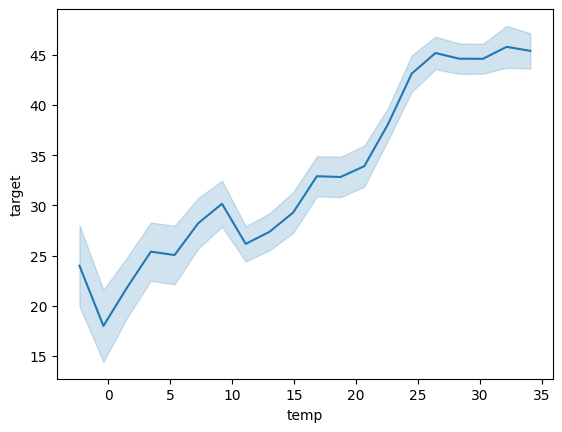

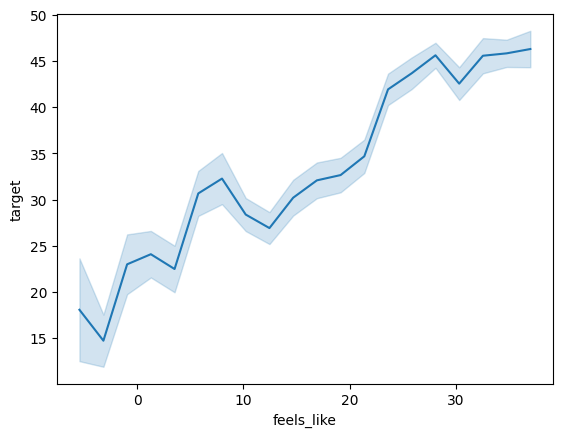

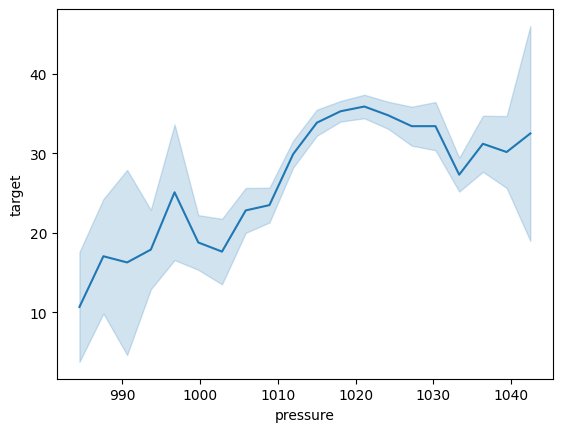

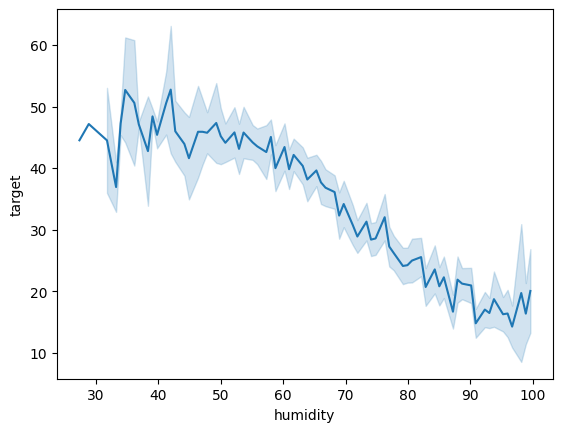

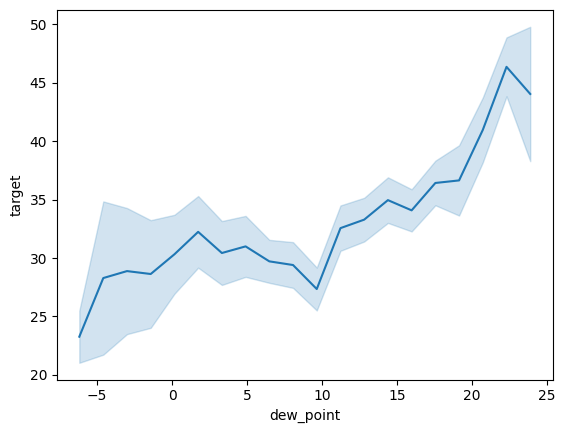

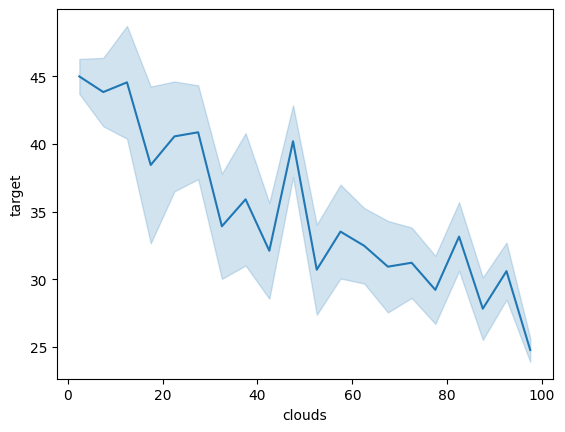

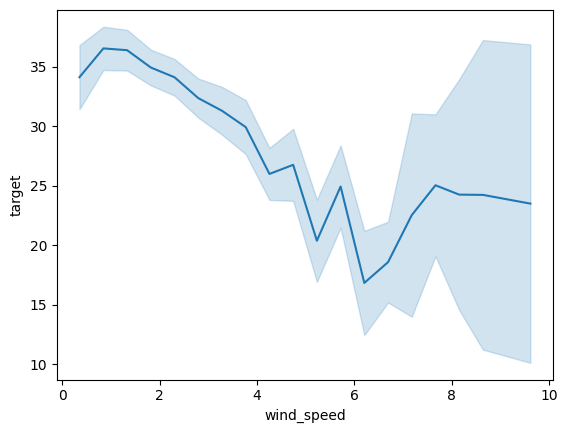

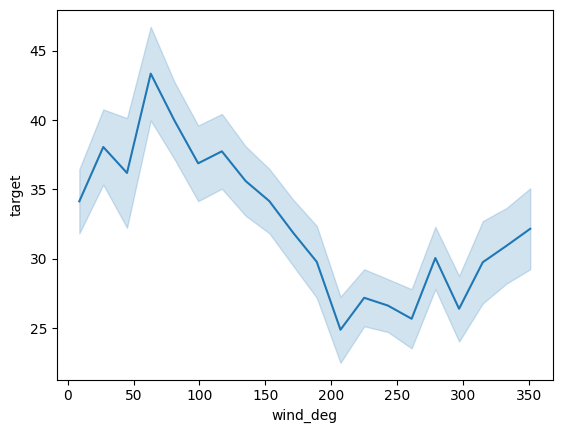

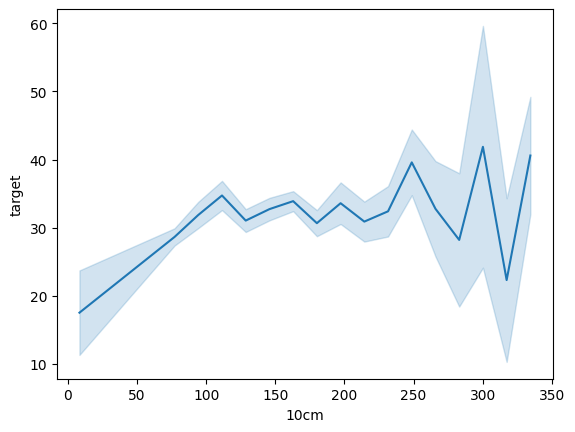

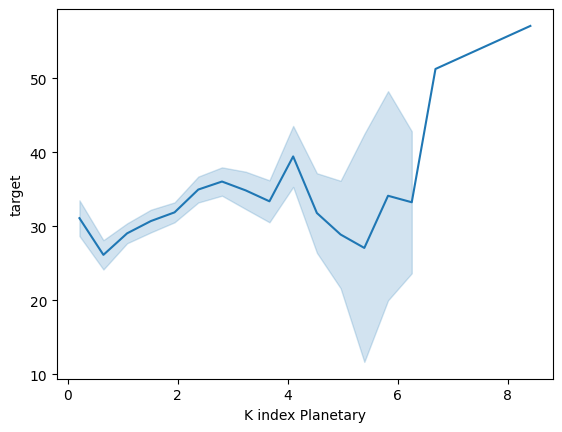

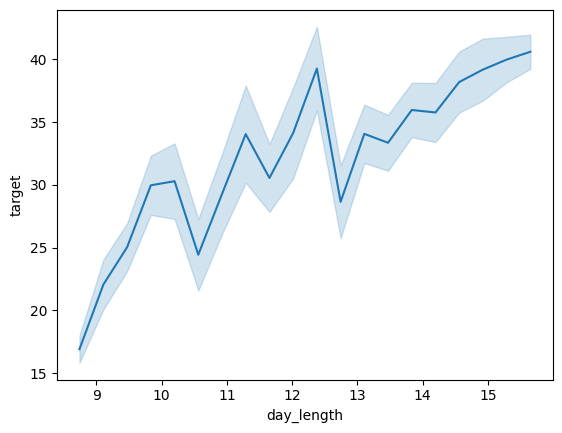

In [42]:
bins = {"temp":20, "feels_like":20, "pressure":20, "humidity":100, "dew_point":20, "clouds":20,
        "wind_speed":20, "wind_deg":20, "10cm":20, "K index Planetary":20, "day_length":20}
quantized_data = pd.DataFrame()
quantized_data['target'] = viz_data['tch_solaire_(%)']

for col in X.columns:
    # Calcul des intervalles avec pd.cut
    cut_result = pd.cut(viz_data[col], bins=bins[col], retbins=True)
    bins_edges = cut_result[1]  # récupère les bornes des bins

    # Créer les labels = médiane de chaque intervalle
    labels = [(bins_edges[i] + bins_edges[i+1])/2 for i in range(len(bins_edges)-1)]

    # Appliquer pd.cut avec labels
    quantized_data[col] = pd.cut(viz_data[col], bins=bins[col], labels=labels)

    plt.figure()
    sns.lineplot(quantized_data, x=col, y='target', errorbar=('se',1.68))
    plt.show()


              feature  importance_mean  importance_std
3            humidity         4.306325        0.328650
10         day_length         1.492183        0.122440
5              clouds         0.552800        0.125192
2            pressure         0.395217        0.126235
4           dew_point         0.360762        0.064510
8                10cm         0.358904        0.083691
6          wind_speed         0.311558        0.114315
0                temp         0.244574        0.027451
1          feels_like         0.160811        0.035842
7            wind_deg         0.073353        0.066531
9   K index Planetary         0.013489        0.050627


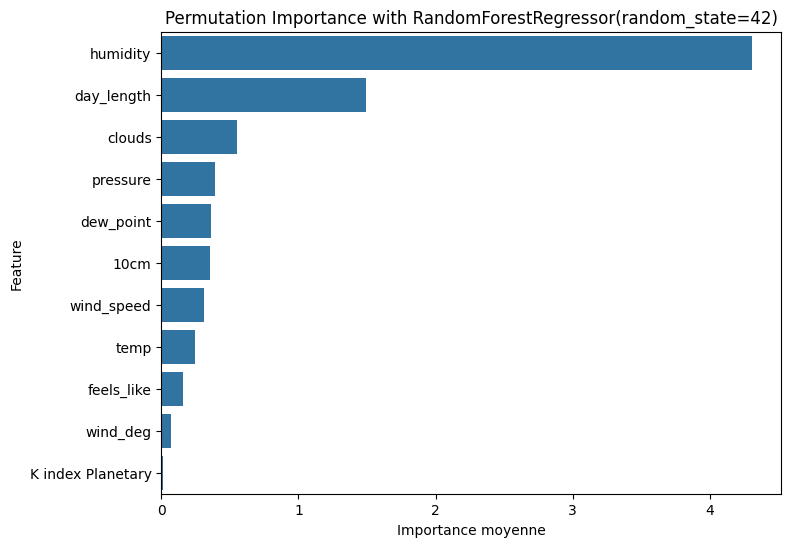

In [43]:
# Exemple avec un DataFrame `X` et une cible `y`
X = viz_data.drop(columns=['tch_solaire_(%)'])
y = viz_data['tch_solaire_(%)']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#entrainement du modele
model = RandomForestRegressor(random_state=42)
#model = LinearRegression()
model.fit(X_train, y_train)

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=30,       # nombre de permutations
    random_state=42,
    scoring='neg_mean_absolute_error'        
)

# Importance moyenne
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

print(importance_df)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x='importance_mean', y='feature', orient='h')
plt.title(f"Permutation Importance with {model}")
plt.xlabel("Importance moyenne")
plt.ylabel("Feature")
plt.show()



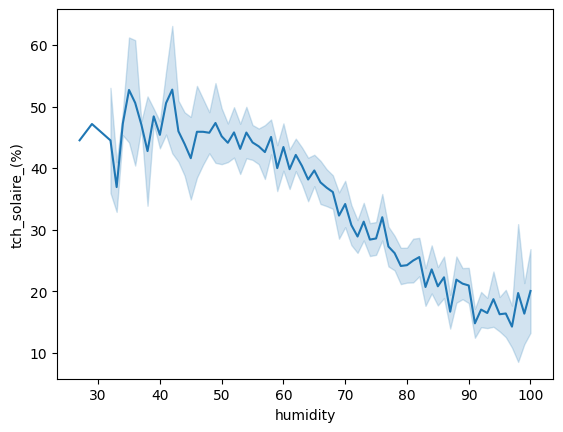

In [44]:
plt.figure()
sns.lineplot(viz_data, x='humidity', y=target, errorbar=('se',1.68))
plt.show()

In [45]:
fig = px.scatter(viz_data, x='humidity', y='tch_solaire_(%)', trendline='ols')
fig.show()